In [20]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

from pathlib import Path
from matplotlib.gridspec import GridSpec

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

od = pd.read_parquet(ROOT / "outputs/od_informality_imputed.parquet")
enoe = pd.read_parquet(ROOT / "outputs/enoe_harmonized.parquet")

with_education_calibration = pd.read_parquet("/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/informal_jobs/notebooks/outputs/calibration_with_education.parquet")
without_education_calibration = pd.read_parquet("/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/informal_jobs/notebooks/outputs/calibration_without_education.parquet")
hybrid_calibration = pd.read_parquet("/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/informal_jobs/notebooks/outputs/calibration_hybrid.parquet")

print(f"OD workers: {len(od):,}")
print(f"ENOE workers: {len(enoe):,}")

OD workers: 26,913
ENOE workers: 6,793


In [21]:
font_paths = list((Path.home() / "Library/Fonts").glob("Montserrat*.ttf")) + list(Path("/Library/Fonts").glob("Montserrat*.ttf"))

for font_path in font_paths:
    fm.fontManager.addfont(str(font_path))

print(fm.findfont("Montserrat", fallback_to_default=False))

/Users/sebastiangutierrezbernal/Library/Fonts/Montserrat-Regular.ttf


In [17]:
from matplotlib.gridspec import GridSpec

sector_labels = {
    "comercio": "Comercio",
    "gobierno_otro_agricultura": "Gobierno,\nAgricultura\nu otro",
    "manufactura_construccion": "Manufactura\ny\nConstrucción",
    "servicios_transporte": "Servicios\ny\nTransporte"
}

sector_order = list(sector_labels.keys())

known_color = (0.06, 0.31, 0.55)
assigned_color = (0.33, 0.53, 0.55)
final_color = (0.36, 0.67, 0.93)

excluded_municipalities = {"otro", "no_especificado"}

enoe_municipalities = set(enoe["municipio"].dropna().astype(str)) - excluded_municipalities
od_municipalities = set(od["municipio"].dropna().astype(str)) - excluded_municipalities
common_municipalities = sorted(enoe_municipalities & od_municipalities)

enoe_final = enoe[enoe["municipio"].isin(common_municipalities)].copy()
enoe_final = enoe_final[enoe_final["informal"].notna()].copy()
enoe_final = enoe_final[enoe_final["sector"].isin(sector_order)].copy()
enoe_final = enoe_final.reset_index(drop=True)

print(f"ENOE workers: {len(enoe_final):,}")
print(f"OD workers: {len(od):,}")

ENOE workers: 5,105
OD workers: 26,913


In [2]:
font_paths = list((Path.home() / "Library/Fonts").glob("Montserrat*.ttf")) + list(Path("/Library/Fonts").glob("Montserrat*.ttf"))

for font_path in font_paths:
    fm.fontManager.addfont(str(font_path))

print(fm.findfont("Montserrat", fallback_to_default=False))

/Users/sebastiangutierrezbernal/Library/Fonts/Montserrat-Regular.ttf


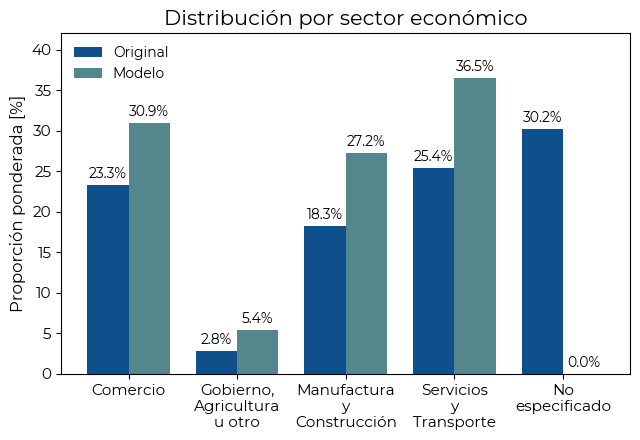

In [14]:
sector_labels = {
    "comercio": "Comercio",
    "gobierno_otro_agricultura": "Gobierno,\nAgricultura\nu otro",
    "manufactura_construccion": "Manufactura\ny\nConstrucción",
    "servicios_transporte": "Servicios\ny\nTransporte",
    "no_especificado": "No\nespecificado"
}

sector_order_initial = ["comercio", "gobierno_otro_agricultura", "manufactura_construccion", "servicios_transporte", "no_especificado"]
sector_order_final = ["comercio", "gobierno_otro_agricultura", "manufactura_construccion", "servicios_transporte"]

known_color = (0.06, 0.31, 0.55)
final_color = (0.33, 0.53, 0.55)

initial_distribution = od.copy()
initial_distribution["sector"] = initial_distribution["sector"].fillna("no_especificado")
initial_distribution = initial_distribution.groupby("sector", as_index=False)["expansion_factor"].sum().rename(columns={"expansion_factor": "weighted_population"})
initial_distribution["weighted_share"] = initial_distribution["weighted_population"] / initial_distribution["weighted_population"].sum()
initial_distribution = initial_distribution.set_index("sector").reindex(sector_order_initial).reset_index()

final_distribution = pd.DataFrame({
    "sector": sector_order_final,
    "weighted_population": [(od["expansion_factor"] * od[f"prob_sector_{sector}"]).sum() for sector in sector_order_final]
})
final_distribution["weighted_share"] = final_distribution["weighted_population"] / final_distribution["weighted_population"].sum()

initial_plot = initial_distribution.copy()
initial_plot["sector"] = initial_plot["sector"].replace(sector_labels)
initial_plot["weighted_share"] *= 100

final_plot = final_distribution.copy()
final_plot = final_plot.set_index("sector").reindex(sector_order_initial).reset_index()
final_plot["weighted_share"] = final_plot["weighted_share"].fillna(0) * 100
final_plot["sector"] = final_plot["sector"].replace(sector_labels)

with mpl.rc_context({"text.usetex": False, "font.family": "sans-serif", "font.sans-serif": ["Montserrat"]}):

    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    x = np.arange(len(initial_plot))
    width = 0.38

    bars_initial = ax.bar(x - width / 2, initial_plot["weighted_share"], width=width, color=known_color, label="Original")
    bars_final = ax.bar(x + width / 2, final_plot["weighted_share"], width=width, color=final_color, label="Modelo")

    ax.bar_label(bars_initial, fmt="%.1f%%", padding=3, fontsize=10)
    ax.bar_label(bars_final, fmt="%.1f%%", padding=3, fontsize=10)

    ax.set_title("Distribución por sector económico", fontsize=15)
    ax.set_xlabel("")
    ax.set_ylabel("Proporción ponderada [%]", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(initial_plot["sector"])
    ax.tick_params(axis="x", rotation=0, labelsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.legend(frameon=False, fontsize=10, loc="upper left")

    max_value = max(initial_plot["weighted_share"].max(), final_plot["weighted_share"].max())
    ax.set_ylim(0, max_value * 1.15)

    output_dir = ROOT / "outputs/figures"
    output_dir.mkdir(parents=True, exist_ok=True)

    plt.tight_layout()

    fig.savefig(output_dir / "sector_original_vs_modelo.pdf", bbox_inches="tight", transparent=True)
    fig.savefig(output_dir / "sector_original_vs_modelo.png", dpi=600, bbox_inches="tight", transparent=True)

    plt.show()

In [22]:
sector_labels = {
    "comercio": "Comercio",
    "gobierno_otro_agricultura": "Gobierno,\nAgricultura\nu otro",
    "manufactura_construccion": "Manufactura\ny\nConstrucción",
    "servicios_transporte": "Servicios\ny\nTransporte"
}

sector_order = list(sector_labels.keys())

known_color = (0.06, 0.31, 0.55)
assigned_color = (0.33, 0.53, 0.55)
final_color = (0.36, 0.67, 0.93)

excluded_municipalities = {"otro", "no_especificado"}

enoe_municipalities = set(enoe["municipio"].dropna().astype(str)) - excluded_municipalities
od_municipalities = set(od["municipio"].dropna().astype(str)) - excluded_municipalities
common_municipalities = sorted(enoe_municipalities & od_municipalities)

enoe_final = enoe[enoe["municipio"].isin(common_municipalities)].copy()
enoe_final = enoe_final[enoe_final["informal"].notna()].copy()
enoe_final = enoe_final[enoe_final["sector"].isin(sector_order)].copy()
enoe_final = enoe_final.reset_index(drop=True)

print(f"ENOE workers used: {len(enoe_final):,}")

ENOE workers used: 5,105


In [23]:
def calibration_r2(calibration_df):
    calibration_data = calibration_df[["observed_rate", "predicted_probability"]].dropna()
    y_true = calibration_data["observed_rate"].to_numpy()
    y_pred = calibration_data["predicted_probability"].to_numpy()
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

r2_with_education = calibration_r2(with_education_calibration)
r2_without_education = calibration_r2(without_education_calibration)
r2_hybrid = calibration_r2(hybrid_calibration)

print(f"R² con escolaridad: {r2_with_education:.4f}")
print(f"R² sin escolaridad: {r2_without_education:.4f}")
print(f"R² híbrido: {r2_hybrid:.4f}")

R² con escolaridad: 0.9492
R² sin escolaridad: 0.9461
R² híbrido: 0.9492


In [24]:
enoe_total_population = enoe_final["survey_weight"].sum()
enoe_informal_population = (enoe_final["survey_weight"] * enoe_final["informal"]).sum()
enoe_formal_population = enoe_total_population - enoe_informal_population

od_total_population = od["expansion_factor"].sum()
od_hard_informal_population = od.loc[od["informal_predicted"] == 1, "expansion_factor"].sum()
od_hard_formal_population = od_total_population - od_hard_informal_population
od_expected_informal_population = (od["expansion_factor"] * od["prob_informal"]).sum()
od_expected_formal_population = od_total_population - od_expected_informal_population

overall_formality_distribution = pd.DataFrame({
    "ENOE": [enoe_formal_population / enoe_total_population, enoe_informal_population / enoe_total_population],
    "OD duro": [od_hard_formal_population / od_total_population, od_hard_informal_population / od_total_population],
    "OD esperado": [od_expected_formal_population / od_total_population, od_expected_informal_population / od_total_population]
}, index=["Formal", "Informal"]) * 100

In [25]:
enoe_informal = enoe_final[enoe_final["informal"] == 1].copy()
enoe_by_sector = enoe_informal.groupby("sector")["survey_weight"].sum().reindex(sector_order, fill_value=0)
enoe_by_sector = enoe_by_sector / enoe_by_sector.sum()

od_hard_informal = od[od["informal_predicted"] == 1].copy()
od_hard_by_sector = od_hard_informal.groupby("sector_final")["expansion_factor"].sum().reindex(sector_order, fill_value=0)
od_hard_by_sector = od_hard_by_sector / od_hard_by_sector.sum()

od_expected_by_sector = pd.Series({
    sector: (od["expansion_factor"] * od[f"prob_informal_sector_{sector}"]).sum()
    for sector in sector_order
})

od_expected_by_sector = od_expected_by_sector / od_expected_by_sector.sum()

informal_distribution_by_sector = pd.DataFrame({
    "ENOE": enoe_by_sector * 100,
    "OD duro": od_hard_by_sector * 100,
    "OD esperado": od_expected_by_sector * 100
})

informal_distribution_by_sector.index = informal_distribution_by_sector.index.map(sector_labels)

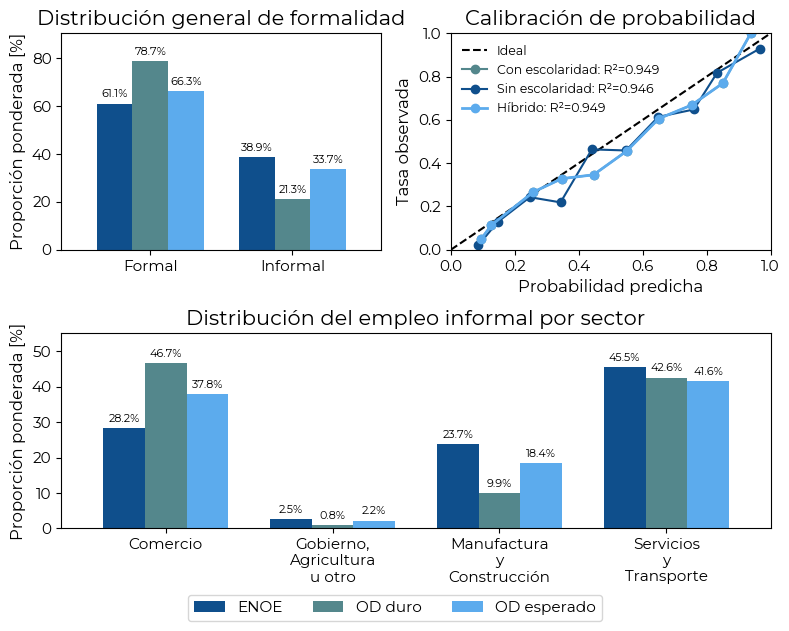

In [36]:
with mpl.rc_context({"text.usetex": False, "font.family": "sans-serif", "font.sans-serif": ["Montserrat"]}):

    fig = plt.figure(figsize=(8, 6.5))

    gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 0.9])

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, :])

    overall_formality_distribution.plot(kind="bar", ax=ax1, color=[known_color, assigned_color, final_color], width=0.75)

    ax1.set_title("Distribución general de formalidad", fontsize=15)
    ax1.set_xlabel("")
    ax1.set_ylabel("Proporción ponderada [%]", fontsize=12)
    ax1.tick_params(axis="x", rotation=0, labelsize=11)
    ax1.tick_params(axis="y", labelsize=11)

    for container in ax1.containers:
        ax1.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)

    ax1.set_ylim(0, overall_formality_distribution.to_numpy().max() * 1.15)

    handles, labels = ax1.get_legend_handles_labels()

    ax1.get_legend().remove()

    ax2.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="Ideal")

    ax2.plot(with_education_calibration["predicted_probability"], with_education_calibration["observed_rate"], marker="o", color=assigned_color, label=f"Con escolaridad: R²={r2_with_education:.3f}")

    ax2.plot(without_education_calibration["predicted_probability"], without_education_calibration["observed_rate"], marker="o", color=known_color, label=f"Sin escolaridad: R²={r2_without_education:.3f}")

    ax2.plot(hybrid_calibration["predicted_probability"], hybrid_calibration["observed_rate"], marker="o", color=final_color, linewidth=2, label=f"Híbrido: R²={r2_hybrid:.3f}")

    ax2.set_title("Calibración de probabilidad", fontsize=15)
    ax2.set_xlabel("Probabilidad predicha", fontsize=12)
    ax2.set_ylabel("Tasa observada", fontsize=12)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.tick_params(axis="x", labelsize=11)
    ax2.tick_params(axis="y", labelsize=11)
    ax2.legend(loc="upper left", frameon=False, fontsize=9)

    informal_distribution_by_sector.plot(kind="bar", ax=ax3, color=[known_color, assigned_color, final_color], width=0.75)

    ax3.set_title("Distribución del empleo informal por sector", fontsize=15)
    ax3.set_xlabel("")
    ax3.set_ylabel("Proporción ponderada [%]", fontsize=12)
    ax3.tick_params(axis="x", rotation=0, labelsize=11)
    ax3.tick_params(axis="y", labelsize=11)

    for container in ax3.containers:
        ax3.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)

    ax3.set_ylim(0, informal_distribution_by_sector.to_numpy().max() * 1.18)

    ax3.get_legend().remove()

    fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=11, bbox_to_anchor=(0.5, 0.025), frameon=True)

    output_dir = ROOT / "outputs/figures"

    output_dir.mkdir(parents=True, exist_ok=True)

    plt.tight_layout(rect=[0, 0.07, 1, 1])

    fig.savefig(output_dir / "informality_model_enoe_od_comparison.pdf", bbox_inches="tight", transparent=True)

    fig.savefig(output_dir / "informality_model_enoe_od_comparison.png", dpi=600, bbox_inches="tight", transparent=True)

    plt.show()